<a href="https://colab.research.google.com/github/akshaybhatt97/365-DAYS-AI-ML-WITH-AKSHAY/blob/main/day_062_distance_metrics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 62/365 — Distance Metrics
## How does KNN decide which points are actually "close"?

Yesterday we explored **K-Nearest Neighbors (KNN)**.

KNN depends on one crucial idea:

**Distance**

To find the nearest neighbors, we need a way to measure how far two observations are from each other.

Today we compare:
- Euclidean Distance
- Manhattan Distance
- Cosine Similarity


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline


## 1. Euclidean Distance

Straight-line distance:

`sqrt((x2-x1)^2 + (y2-y1)^2)`


In [2]:
A=np.array([2,3])
B=np.array([5,7])

euclidean=np.sqrt(np.sum((A-B)**2))
print("Euclidean distance:",round(euclidean,3))


Euclidean distance: 5.0


## 2. Manhattan Distance

Grid-style distance:

`|x2-x1| + |y2-y1|`


In [3]:
manhattan=np.sum(np.abs(A-B))
print("Manhattan distance:",round(manhattan,3))


Manhattan distance: 7


## 3. Cosine Similarity

Cosine similarity compares the **direction** of vectors:

`cos(theta) = (A · B) / (||A|| ||B||)`


In [4]:
cosine_similarity=np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))
cosine_distance=1-cosine_similarity

print("Cosine similarity:",round(cosine_similarity,3))
print("Cosine distance:",round(cosine_distance,3))


Cosine similarity: 0.999
Cosine distance: 0.001


## 4. Visualize Euclidean vs Manhattan


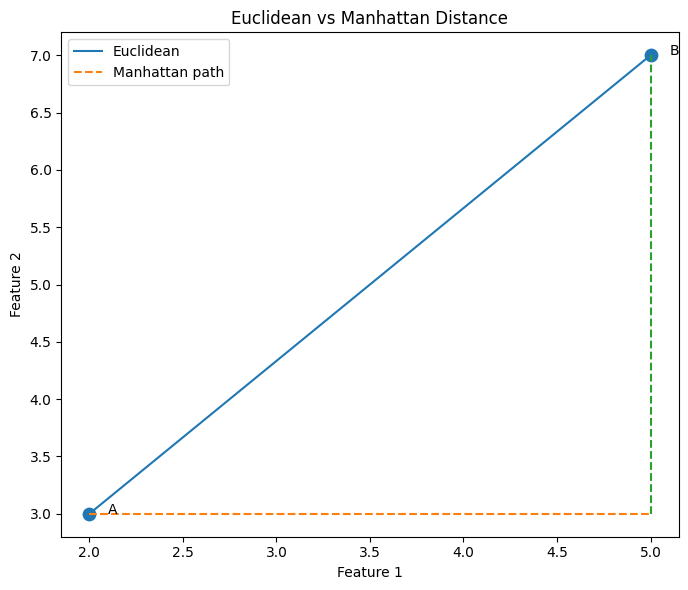

In [5]:
plt.figure(figsize=(7,6))
plt.scatter([A[0],B[0]],[A[1],B[1]],s=80)
plt.plot([A[0],B[0]],[A[1],B[1]],label="Euclidean")
plt.plot([A[0],B[0]],[A[1],A[1]],linestyle="--",label="Manhattan path")
plt.plot([B[0],B[0]],[A[1],B[1]],linestyle="--")
plt.text(A[0]+0.1,A[1],"A")
plt.text(B[0]+0.1,B[1],"B")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Euclidean vs Manhattan Distance")
plt.legend()
plt.tight_layout()
plt.show()


## 5. Why scaling matters

Distance is sensitive to scale.

If Age ranges from 20–70 but Income ranges from 20,000–200,000, Income can dominate the distance.

That is why distance-based models usually need feature scaling.


## 6. Real KNN experiment


In [6]:
data=load_breast_cancer(as_frame=True)
X=data.data
y=data.target

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.25,random_state=42,stratify=y
)

results=[]

for metric in ["euclidean","manhattan"]:
    model=Pipeline([
        ("scaler",StandardScaler()),
        ("knn",KNeighborsClassifier(
            n_neighbors=5,
            metric=metric
        ))
    ])

    model.fit(X_train,y_train)
    accuracy=accuracy_score(
        y_test,
        model.predict(X_test)
    )

    results.append({
        "Distance Metric":metric.title(),
        "Test Accuracy":accuracy
    })

results=pd.DataFrame(results)
display(results.round(3))


,Distance Metric,Test Accuracy
0,Euclidean,0.979
1,Manhattan,0.965


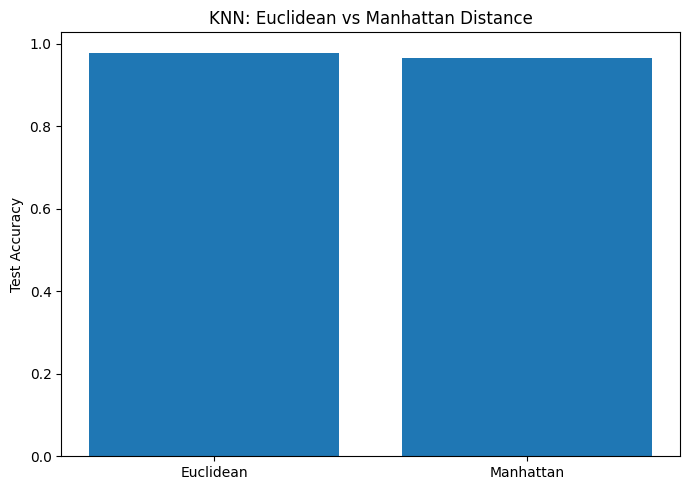

In [7]:
plt.figure(figsize=(7,5))
plt.bar(results["Distance Metric"],results["Test Accuracy"])
plt.ylabel("Test Accuracy")
plt.title("KNN: Euclidean vs Manhattan Distance")
plt.tight_layout()
plt.show()


## 7. Where Cosine Similarity shines

Cosine similarity is common when vector **direction** matters more than magnitude.

Typical uses:
- text similarity
- embeddings
- semantic search
- recommendation systems
- vector databases


## Enterprise intuition

### Euclidean Distance
Useful when numerical geometry matters and features are scaled.

### Manhattan Distance
Useful when absolute coordinate differences are meaningful.

### Cosine Similarity
Useful when comparing vector direction, especially in text and embedding systems.

There is no universally best distance metric.

The right choice depends on the meaning of the data.


## What does this teach?

- KNN needs a distance metric to define "nearest".
- Euclidean = straight-line distance.
- Manhattan = sum of absolute differences.
- Cosine = similarity of direction.
- Scaling strongly affects distance-based models.
- Different metrics can produce different neighbors and predictions.

> **Before asking which points are nearest, we first have to define what "near" actually means.**


## References

- https://scikit-learn.org/stable/modules/neighbors.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.DistanceMetric.html
- https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html
- https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html
